In [7]:
import pandas as pd
import pickle
from pathlib import Path

df  = pd.read_parquet("data.parquet")

# affiche les nombres sans notation scientifique avec pandas
pd.set_option("display.float_format", "{:,.2f}".format)

# Chargement du dataset
X_test  = pd.read_parquet("X_test.parquet")
y_test  = pd.read_parquet("y_test.parquet")
X_train  = pd.read_parquet("X_train.parquet")
y_train  = pd.read_parquet("y_train.parquet")

# Chargement des catégories
with open("categories.pkl", "rb") as f:
    categories = pickle.load(f)

# stockage des metriques
global_metrics = []

# crée les dossiers
Path("tests").parent.mkdir(parents=True, exist_ok=True)
Path("database").parent.mkdir(parents=True, exist_ok=True)
Path("models").parent.mkdir(parents=True, exist_ok=True)

À partir du texte d'une réclamation, prédire automatiquement son Tag

l'objectif est de déterminer si le contenu de la réclamation permet lui-même d'identifier la catégorie.

In [ ]:
print("Longueur du test initial :", len(X_test))
print("Longueur du train initial :", len(X_train))

# dans cette approche, on prédit le Tag à partir du texte de réclamation
# Cela permet d'avoir une comparaison avec l'approche LLM
filter = (X_test["Consumer Claim"].isna() == False & X_test["Consumer Claim"].str.strip().ne(""))
X_test  = X_test[filter]["Consumer Claim"]
y_test  = y_test[filter]["Tag"]

filter = (X_train["Consumer Claim"].isna() == False & X_train["Consumer Claim"].str.strip().ne(""))
X_train  = X_train[filter]["Consumer Claim"]
y_train  = y_train[filter]["Tag"]

print("Longueur du test filtré  :", len(X_test))
print("Longueur du train filtré  :", len(X_train))

# Fonctions de stockage des résultats

In [9]:
import pickle
from pathlib import Path

def load_results(results_path):
    if results_path.exists():
        # sauvegarde également les différentes catègories
        with open(results_path, "rb") as f:
            return pickle.load(f)
    else:
        return pd.DataFrame()
        
def save_results(results, results_path):
    # sauvegarde également les différentes catègories
    with open(results_path, "wb") as f:
        pickle.dump(results, f)

# Fonction de test

In [10]:
from collections.abc import Callable
import time
import pandas as pd


def test(
    indices,
    model,
    **kwargs
) -> pd.DataFrame:
    """
    Évalue les performances du modèle de classification sur un ensemble
    d'indices du jeu de test.

    Pour chaque réclamation, la fonction construit éventuellement un prompt
    complémentaire, puis effectue la classification via `with_retry`.
    Le prompt complémentaire peut être fourni directement sous forme de
    chaîne de caractères ou être généré dynamiquement par une fonction.

    Args:
        indices:
            Collection d'indices correspondant aux lignes de `X_test` et
            `y_test` à utiliser pour l'évaluation.

        additional_prompt (str | Callable[[str], str] | None, optional):
            Prompt complémentaire à ajouter au prompt de classification.

            Trois comportements sont possibles :

            - `None` : aucun prompt complémentaire.
            - `str` : le même prompt est utilisé pour toutes les questions.
            - `Callable[[str], str]` : la fonction est appelée pour chaque
              question avec le texte de la réclamation comme argument.
              Elle doit retourner le prompt complémentaire à utiliser.

    Returns:
        pd.DataFrame:
            Tableau récapitulatif contenant les résultats de chaque test.

            Colonnes :
            - `Index` : index de la réclamation.
            - `Question` : réclamation testée.
            - `Réponse` : catégorie prédite.
            - `Attendue` : catégorie réelle.
            - `Correct` : indique si la prédiction est correcte.
            - `Temps (s)` : temps nécessaire pour obtenir la réponse.

    Raises:
        TypeError:
            Si `additional_prompt` n'est ni `None`, ni une chaîne de
            caractères, ni une fonction appelable.

    Example:
        # Prompt fixe
        results = test(
            indices,
            additional_prompt="Soyez particulièrement attentif..."
        )

        # Prompt généré dynamiquement
        def get_examples(question):
            examples = retrieve_examples(
                metadata,
                question,
                k=3
            )

            return format_examples(examples)

        results = test(
            indices,
            additional_prompt=get_examples
        )
    """

    results = []


    for idx in indices:
        X = X_test.loc[idx]
        y = y_test.loc[idx]

        question = X
        expected = y

        start = time.perf_counter()

        y_pred = model.predict([X])

        elapsed = time.perf_counter() - start

        results.append({
            "Index": idx,
            "Question": question,
            "Réponse": y_pred[0],
            "Attendue": expected,
            "Correct": y_pred[0] == expected,
            "Temps (s)": elapsed
        })

    return pd.DataFrame(results)

## TF-IDF

**TF-IDF est une méthode qui permet de transformer des textes en vecteurs numériques, afin qu'un algorithme de machine learning puisse les exploiter.**

transforme Consumer Claim en données numériques avant d'être utilisé par un modèle tel que régression-logistique, SVM ou Random Forest.

TF-IDF signifie Term Frequency – Inverse Document Frequency.

L'idée générale est simple : un mot doit avoir un poids élevé s'il est important dans une réclamation, mais un poids faible s'il apparaît dans presque toutes les réclamations.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

vectorizer_path = Path("models","tfidf_vectorizer.joblib")
try:
    print(vectorizer_path, ": Charge le modèle existant...")
    vectorizer = joblib.load(vectorizer_path)
except Exception as e:
    print(e)
    print(vectorizer_path, ": Entraine un nouveau modèle... ")
    start = time.perf_counter()

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2), # (1, 2) suffit souvent et évite l'explosion de mémoire subie avec (1, 3)
        min_df=10,
        max_df=0.85,
        max_features=100000,
        sublinear_tf=True,
        stop_words=['xxxx', 'xx', 'xxxx xxxx'] # Nettoyer les masques anonymisés CFPB
    )
    
    # L'entrainement est réalisé uniquement sur le train
    vectorizer.fit(X_train)

    elapsed = time.perf_counter() - start
    print("Terminé en ", elapsed / 60 if elapsed > 60 else elapsed," (min)" if elapsed > 60 else " (s)")

    # Sauvegarde le modèle entraîné
    joblib.dump(vectorizer, vectorizer_path)


# transforme les données en vecteur
X_train_tfidf = vectorizer.transform(X_train)

models\tfidf_vectorizer.joblib : Charge le modèle existant...
[Errno 2] No such file or directory: 'models\\tfidf_vectorizer.joblib'
models\tfidf_vectorizer.joblib : Entraine un nouveau modèle... 
Terminé en  1.5112140816667912  (min)


In [12]:
print("Nombre de features :", len(vectorizer.vocabulary_))
print("Shape :", X_train_tfidf.shape)
print("Noms des features (", len(vectorizer.get_feature_names_out()), "): ", vectorizer.get_feature_names_out())

Nombre de features : 100000
Shape : (306773, 100000)
Noms des features ( 100000 ):  ['00' '00 00' '00 10' ... 'zone' 'zone and' 'zwicker']


## Modèle 1 : TF-IDF + Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

classifier_path = Path("models","logistic_regression.joblib")
try:
    print(classifier_path, ": Charge le modèle existant...")
    classifier = joblib.load(classifier_path)
except Exception as e:
    print(e)
    print(classifier_path, ": Entraine un nouveau modèle... ")
    start = time.perf_counter()

    classifier = LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )
    classifier.fit(X_train_tfidf, y_train)

    elapsed = time.perf_counter() - start
    print("Terminé en ", elapsed / 60 if elapsed > 60 else elapsed," (min)" if elapsed > 60 else " (s)")
    
    # Sauvegarde le modèle entraîné
    joblib.dump(classifier, classifier_path)

models\logistic_regression.joblib : Charge le modèle existant...
[Errno 2] No such file or directory: 'models\\logistic_regression.joblib'
models\logistic_regression.joblib : Entraine un nouveau modèle... 
Terminé en  4.314206813333537  (min)


In [14]:
from pathlib import Path
from sklearn.pipeline import Pipeline
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

name = "TF-IDF + Logistic Regression"
method = "LogisticRegression"
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)
 
model = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", classifier)
])

if len(results) == 0:
    print("Démarre le test:", name)
    indices = X_test.index
    results = test(indices, model)
    save_results(results, results_path)

metrics = calculate_metrics(name, method, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)

global_metrics.append(metrics)

Démarre le test: TF-IDF + Logistic Regression

------------------------
TF-IDF + Logistic Regression
------------------------
Name : TF-IDF + Logistic Regression
Method : LogisticRegression
Samples : 76791
Accuracy : 83.13%
Precision (macro) : 68.97%
Recall (macro) : 74.18%
F1 (macro) : 71.15%
Precision (weighted) : 84.17%
Recall (weighted) : 83.13%
F1 (weighted) : 83.46%
Temps moyen (s) : 0.0008 s
Temps médian (s) : 0.0007 s
Temps P95 (s) : 0.0013 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.80      0.85      0.82      5530
                                                 Credit card or prepaid card       0.79      0.83      0.81      8446
Credit reporting, credit repair services, or other personal consumer reports       0.91      0.81      0.86     24675
                                              

## Modèle 2 : TF-IDF + Linear SVM

In [15]:
from sklearn.svm import LinearSVC

svm_path = Path("models","svm.joblib")
try:
    print(svm_path, ": Charge le modèle existant...")
    svm = joblib.load(svm_path)
except Exception as e:
    print(e)
    print(svm_path, ": Entraine un nouveau modèle... ")
    start = time.perf_counter()
    
    svm = LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=5000
    )
    svm.fit(X_train_tfidf, y_train)

    elapsed = time.perf_counter() - start
    print("Terminé en ", elapsed / 60 if elapsed > 60 else elapsed," (min)" if elapsed > 60 else " (s)")
    
    # Sauvegarde le modèle entraîné
    joblib.dump(svm, svm_path)

models\svm.joblib : Charge le modèle existant...
[Errno 2] No such file or directory: 'models\\svm.joblib'
models\svm.joblib : Entraine un nouveau modèle... 
Terminé en  3.012729651666693  (min)


In [16]:
from pathlib import Path
from sklearn.pipeline import Pipeline
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

name = "TF-IDF + Linear SVC"
method = "LinearSVC"
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)
 
model = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", svm)
])

if len(results) == 0:
    print("Démarre le test:", name)
    indices = X_test.index
    results = test(indices, model)
    save_results(results, results_path)

metrics = calculate_metrics(name, method, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)

global_metrics.append(metrics)

Démarre le test: TF-IDF + Linear SVC

------------------------
TF-IDF + Linear SVC
------------------------
Name : TF-IDF + Linear SVC
Method : LinearSVC
Samples : 76791
Accuracy : 84.96%
Precision (macro) : 73.78%
Recall (macro) : 70.50%
F1 (macro) : 70.90%
Precision (weighted) : 85.01%
Recall (weighted) : 84.96%
F1 (weighted) : 84.96%
Temps moyen (s) : 0.0008 s
Temps médian (s) : 0.0007 s
Temps P95 (s) : 0.0013 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.79      0.83      0.81      5530
                                                 Credit card or prepaid card       0.80      0.83      0.81      8446
Credit reporting, credit repair services, or other personal consumer reports       0.91      0.87      0.89     24675
                                                             Debt collection      

## Modèle 3 : TF-IDF + Naive Bayes

In [17]:
from sklearn.naive_bayes import ComplementNB

nb_path = Path("models","nb.joblib")
try:
    print(nb_path, ": Charge le modèle existant...")
    nb = joblib.load(nb_path)
except Exception as e:
    print(e)
    print(nb_path, ": Entraine un nouveau modèle... ")
    start = time.perf_counter()
    
    nb = ComplementNB()
    nb.fit(X_train_tfidf, y_train)

    elapsed = time.perf_counter() - start
    print("Terminé en ", elapsed / 60 if elapsed > 60 else elapsed," (min)" if elapsed > 60 else " (s)")
    
    # Sauvegarde le modèle entraîné
    joblib.dump(nb, nb_path)

models\nb.joblib : Charge le modèle existant...
[Errno 2] No such file or directory: 'models\\nb.joblib'
models\nb.joblib : Entraine un nouveau modèle... 
Terminé en  2.2745999000035226  (s)


In [18]:
from pathlib import Path
from sklearn.pipeline import Pipeline
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

name = "TF-IDF + Complement NB"
method = "ComplementNB"
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)
 
model = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", nb)
])

if len(results) == 0:
    print("Démarre le test:", name)
    indices = X_test.index
    results = test(indices, model)
    save_results(results, results_path)

metrics = calculate_metrics(name, method, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)

global_metrics.append(metrics)

Démarre le test: TF-IDF + Complement NB

------------------------
TF-IDF + Complement NB
------------------------
Name : TF-IDF + Complement NB
Method : ComplementNB
Samples : 76791
Accuracy : 80.03%
Precision (macro) : 67.39%
Recall (macro) : 58.41%
F1 (macro) : 59.41%
Precision (weighted) : 79.22%
Recall (weighted) : 80.03%
F1 (weighted) : 78.75%
Temps moyen (s) : 0.0029 s
Temps médian (s) : 0.0029 s
Temps P95 (s) : 0.0036 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.73      0.82      0.77      5530
                                                 Credit card or prepaid card       0.76      0.78      0.77      8446
Credit reporting, credit repair services, or other personal consumer reports       0.83      0.86      0.85     24675
                                                             Debt coll

# Tableau comparatif synthétique des métriques

In [19]:
global_metrics_df = pd.DataFrame(
    global_metrics,
    columns=["Name", "Samples", "Method", "Accuracy", "F1 (macro)", "F1 (weighted)", "Temps moyen (s)"]
    )

global_metrics_df = global_metrics_df.rename(columns={
    "Name" : "Configuration du Test",
    "Samples" : "Échantillon (N)",
    "Method" : "Modèle",
    "Accuracy": "Accuracy",
    "F1 (macro)": "F1-Score (m)",
    "F1 (weighted)": "F1-Score (w)",
    "Temps moyen (s)" : "Temps Moyen (s)"
})


pd.set_option("display.float_format", "{:,.3f}".format)

global_metrics_df

,Configuration du Test,Échantillon (N),Modèle,Accuracy,F1-Score (m),F1-Score (w),Temps Moyen (s)
0,TF-IDF + Logistic Regression,76791,LogisticRegression,0.831,0.712,0.835,0.001
1,TF-IDF + Linear SVC,76791,LinearSVC,0.850,0.709,0.850,0.001
2,TF-IDF + Complement NB,76791,ComplementNB,0.800,0.594,0.787,0.003


## Analyse par catégorie

L'accuracy globale ne permet pas de savoir si le modèle sait correctement traiter les petites catégories.

La différence de score entre F1 (macro) et F1 (weighted) montre qu'il y a un déséquilibre des prédictions en fonction des classes

In [20]:
from sklearn.metrics import classification_report

name = "TF-IDF + Linear SVC"
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)


y_test = results["Attendue"]
y_pred_svc = results["Réponse"]

print(
    classification_report(
        y_test,
        y_pred_svc,
        zero_division=0
    )
)

                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.79      0.83      0.81      5530
                                                 Credit card or prepaid card       0.80      0.83      0.81      8446
Credit reporting, credit repair services, or other personal consumer reports       0.91      0.87      0.89     24675
                                                             Debt collection       0.85      0.85      0.85     17424
                          Money transfer, virtual currency, or money service       0.76      0.72      0.74      1447
                                                                    Mortgage       0.91      0.94      0.93     10571
                                                     Other financial service       0.45      0.09      0.15        55
                                   Payday loan, title l

# Analyse des erreurs de classification

In [21]:
# Construire un DataFrame d'analyse des erreurs
errors = results[
    results["Correct"] == False
].copy()

errors[
    ["Question", "Attendue", "Réponse"]
]

,Question,Attendue,Réponse
4,"On XXXX XXXX, XXXX, we turned-over our XXXX XX...","Payday loan, title loan, or personal loan",Vehicle loan or lease
6,I contacted CFPB two years ago about how Bayvi...,Mortgage,Debt collection
9,To whom it may concern On XX/XX/XXXX Radius Gl...,"Credit reporting, credit repair services, or o...",Debt collection
13,XXXX XXXX XXXX XXXX contacted me about a credi...,Debt collection,Credit card or prepaid card
16,I had been using XXXX XXXX to monitor my credi...,Mortgage,"Credit reporting, credit repair services, or o..."
...,...,...,...
76730,XX/XX/XXXX I awoke to a series of emails from ...,"Money transfer, virtual currency, or money ser...",Credit card or prepaid card
76737,GM Financial is reporting an inaccurate late o...,"Credit reporting, credit repair services, or o...","Payday loan, title loan, or personal loan"
76744,COMPLAINTANT 'S ADDRESS : XXXX XXXX XXXX. XXXX...,Debt collection,Credit card or prepaid card
76745,All but XXXX,"Credit reporting, credit repair services, or o...",Debt collection


In [87]:
confusions = (
    errors
    .groupby(["Attendue", "Réponse"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusions["% ERR"] = (
    confusions["count"] / len(errors) * 100
)

confusions["% VOL"] = (
    confusions["count"] / len(results) * 100
)

confusions.head(20)

,Attendue,Réponse,count,% ERR,% VOL
19,"Credit reporting, credit repair services, or o...",Debt collection,1370,11.862,1.784
28,Debt collection,"Credit reporting, credit repair services, or o...",1043,9.031,1.358
18,"Credit reporting, credit repair services, or o...",Credit card or prepaid card,607,5.256,0.790
10,Credit card or prepaid card,"Credit reporting, credit repair services, or o...",444,3.844,0.578
9,Credit card or prepaid card,Checking or savings account,428,3.706,0.557
27,Debt collection,Credit card or prepaid card,402,3.481,0.523
83,Vehicle loan or lease,"Payday loan, title loan, or personal loan",400,3.464,0.521
0,Checking or savings account,Credit card or prepaid card,397,3.438,0.517
32,Debt collection,"Payday loan, title loan, or personal loan",387,3.351,0.504
64,"Payday loan, title loan, or personal loan",Debt collection,383,3.316,0.499


Le Top 4 des confusions est :
* Credit reporting, credit repair services, or other personal consumer reports
* Debt collection
* Credit card or prepaid card
* Vehicle loan or lease	

In [23]:
print(f"Nombre d'erreurs : {len(errors)}")
print(f"Taux d'erreur : {len(errors) / len(results):.2%}")

Nombre d'erreurs : 11549
Taux d'erreur : 15.04%


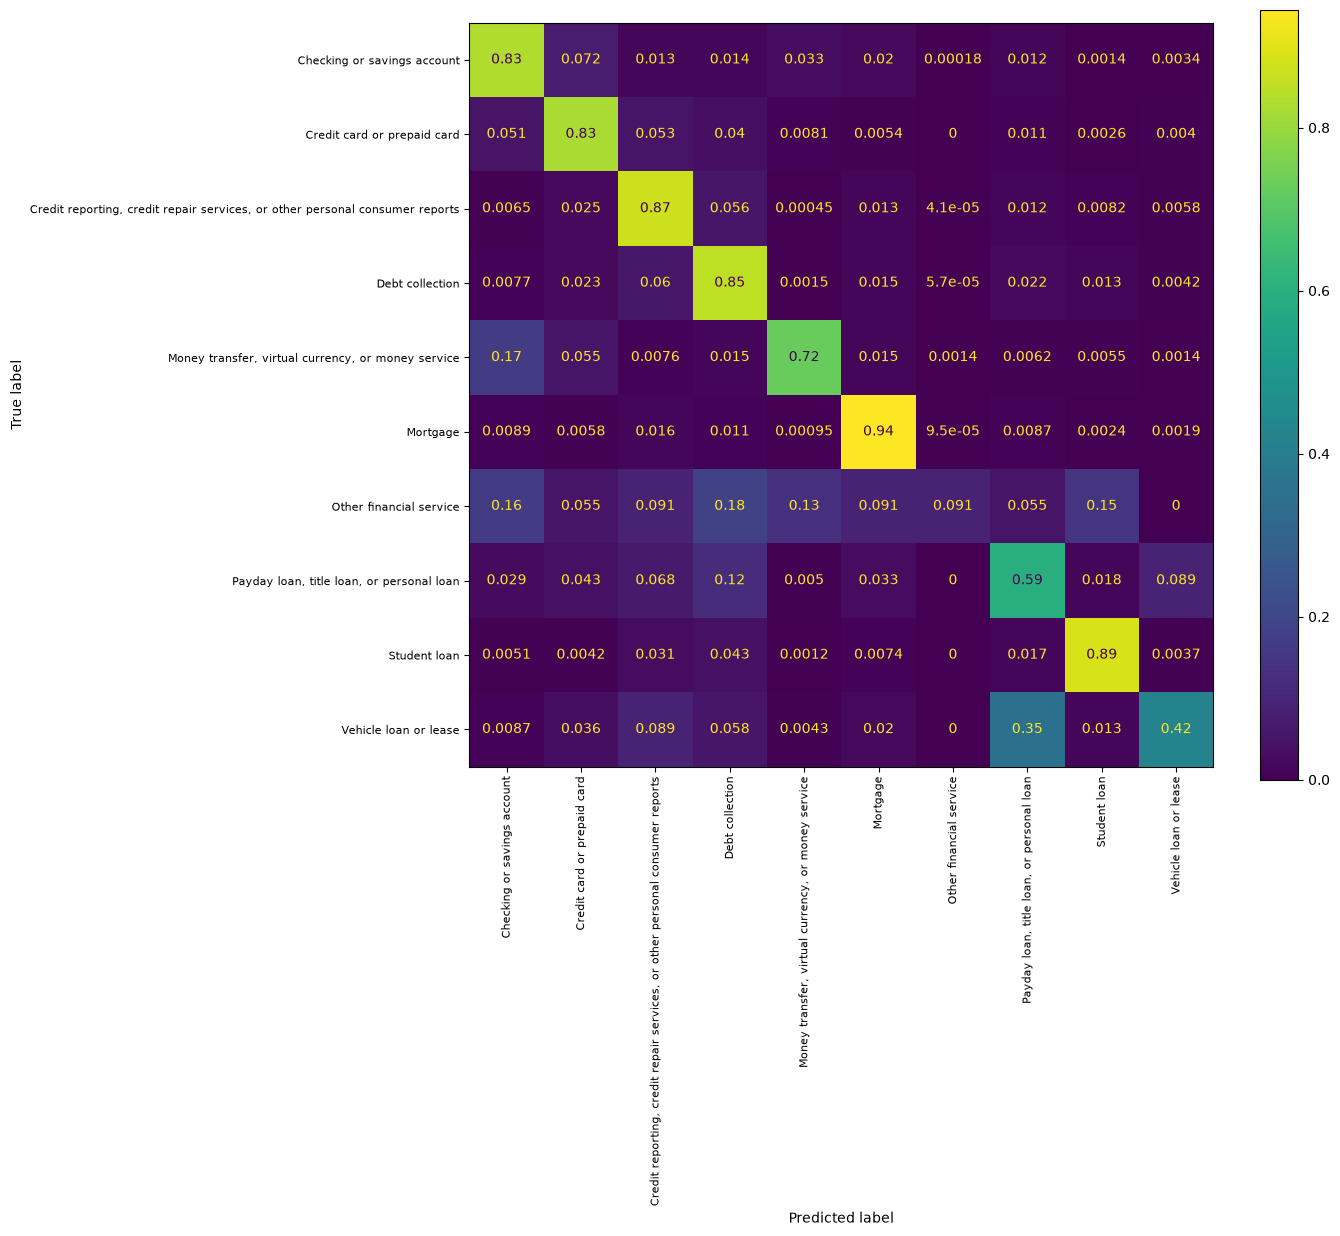

In [24]:
# Matrice de confusion

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svc,
    xticks_rotation=90,
    normalize="true",
    ax=ax
)

ax.tick_params(axis="both", labelsize=8)

plt.show()

In [84]:
for category in [
    "Other financial service",
    "Vehicle loan or lease",
    "Payday loan, title loan, or personal loan"
]:
    print(category)

    display(
        errors[
            errors["Attendue"] == category
        ][
            ["Question", "Réponse"]
        ].head(20)
    )

Other financial service


,Question,Réponse
1455,Returning to the XXXX I exchanged XXXX at the ...,Debt collection
1595,I attempted to contact Navient to discuss my s...,Student loan
2006,In XXXX of 2016 I went under contract for a ne...,Mortgage
3610,"I was trying to purchase a home, however my cr...",Debt collection
7142,Santander Bank has not issued a refund check f...,Credit card or prepaid card
12276,I was contacted by National Budget Planners an...,Student loan
15726,I was notified by a creditor that my personal ...,"Credit reporting, credit repair services, or o..."
16445,Centegy has on multipal occasions denied my pa...,Checking or savings account
16642,I was initially denied the ability to cash a c...,"Money transfer, virtual currency, or money ser..."
17240,I contacted XXXX for student loan consolidat...,Student loan


Vehicle loan or lease


,Question,Réponse
81,I was sent a letter from XXXX XXXX XXXXXXXX de...,Debt collection
313,I purchased an used car at XXXX XXXX and was ...,"Payday loan, title loan, or personal loan"
350,My spouse and I both have Chase Auto Credit lo...,"Payday loan, title loan, or personal loan"
483,I traded a car that was financed through PNC B...,"Payday loan, title loan, or personal loan"
500,I applied directly with XXXX this a.m. of XXXX...,"Credit reporting, credit repair services, or o..."
630,I have an auto loan through USAA. I made an ad...,Mortgage
715,A Santander Consumer account that was open in ...,"Credit reporting, credit repair services, or o..."
769,I recently relocated to XXXX XXXX XXXX for wor...,"Payday loan, title loan, or personal loan"
884,XXXX XXXX XXXX hasn't removed 3 claimed late p...,"Credit reporting, credit repair services, or o..."
923,cap-one finance has this excellent program tha...,"Payday loan, title loan, or personal loan"


Payday loan, title loan, or personal loan


,Question,Réponse
4,"On XXXX XXXX, XXXX, we turned-over our XXXX XX...",Vehicle loan or lease
64,My name is XXXX XXXX XXXX. I sent Tower Loan a...,Debt collection
116,I asked for {$1800.00} they approved me then w...,Debt collection
137,An outside company keeps calling me and threat...,Debt collection
158,I am an Amazon Prime customer & I purchased a ...,Credit card or prepaid card
288,I initiated voluntary repossession on XXXX veh...,Debt collection
311,XXXX XXXX from XXXX ..she said she was calling...,Debt collection
385,"In talking to a customer service rep, I was as...","Credit reporting, credit repair services, or o..."
394,Will call several times a day although permiss...,Student loan
443,My payment is listed as 30 days late on XXXX c...,"Credit reporting, credit repair services, or o..."


* `Other financial service` est très varié
* `Vehicle loan or lease` est souvant confondu avec `Credit reporting, credit repair services, or o...` ou `Payday loan, title loan, or personal loan`
* `Payday loan, title loan, or personal loan` est souvant confondu avec `Debt collection`, `Credit card or prepaid card` ou `Vehicle loan or lease`

# Détermine si la marge de décision peut être un indicateur de score

## Comment fonctionne cette méthode (Marge d'hyperplan)

Dans une classification multi-classes de type One-vs-Rest (par défaut dans LinearSVC), le modèle entraîne un hyperplan de séparation pour chaque catégorie.

Pour une réclamation donnée :

1. svm.decision_function() calcule une note (score géométrique) pour chaque classe disponible. Plus ce score est élevé et positif, plus le texte est distant de la frontière de séparation et "appartient" à cette classe.
2. np.sort(scores, axis=1) trie ces notes par ordre croissant pour chaque réclamation.
3. sorted_scores[:, -1] correspond au score de la classe gagnante (la prédiction finale).
4. sorted_scores[:, -2] correspond au score de la deuxième meilleure classe (le principal challenger).

* Si la marge est grande : Le modèle a une classe très nettement détachée des autres. Il est confiant.
* Si la marge est faible (proche de 0) : Deux classes se disputent la réponse. Le modèle hésite.


## Analyse des résultats avec describe()

Les données confirment mathématiquement l'utilité du score :

Prédictions correctes (True) :

* La marge médiane (50%) est de 1,768 et la moyenne est de 1,830.
* 75 % des bonnes réponses ont une marge supérieure à 1,020.

Prédictions incorrectes (False) :

* La marge médiane (50%) tombe à 0,449 (environ 4 fois plus faible que pour les bonnes prédictions).
* 25 % des erreurs se situent sous une marge très faible de 0,187.

Conclusion : Les erreurs du modèle se concentrent très majoritairement sur des zones à faible marge.

In [42]:
import numpy as np

# 1. Vectoriser l'ensemble du jeu de test (résultats)
results_tfidf = vectorizer.transform(results["Question"])

# 2. Calculer les scores de décision pour toutes les prédictions
all_scores = svm.decision_function(results_tfidf)

# 3. Trier les scores et calculer la marge (1er score - 2e score)
all_sorted_scores = np.sort(all_scores, axis=1)
results["Margin"] = all_sorted_scores[:, -1] - all_sorted_scores[:, -2]

# 4. Comparer les marges selon la justesse (True vs False)
print(results.groupby("Correct")["Margin"].describe())

             count  mean   std   min   25%   50%   75%   max
Correct                                                     
False   11,549.000 0.649 0.631 0.000 0.187 0.449 0.926 5.123
True    65,242.000 1.830 1.033 0.000 1.020 1.768 2.547 6.753


| Métrique | Prédictions Incorrectes (False) | Prédictions Correctes (True) | Interprétation métier
|----------|---------------------------------|------------------------------|-------------------
| Volume (count) | 11 549 réclamations | 65 242 réclamations | Taux d'exactitude global d'environ 84,9 % sur ce jeu de test.
| Moyenne (mean) | 0,649 | 1,830 | La marge moyenne des prédictions correctes est 2,8 fois plus élevée que celle des erreurs.
| Médiane (50%) | 0,449 | 1,768 | 50 % des erreurs ont une marge inférieure à 0,45, alors que 50 % des bonnes réponses ont une marge supérieure à 1,77.
| 1er Quartile (25%) | 0,187 | 1,020 | 75 % des prédictions correctes ont une marge supérieure à 1,02, contre seulement 25 % pour les erreurs.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

# 1. Envelopper le modèle déjà entraîné (svm) dans un FrozenEstimator
frozen_svm = FrozenEstimator(svm)

# 2. Instancier le calibrateur avec l'estimateur figé
calibrated_svm = CalibratedClassifierCV(frozen_svm)

# 3. Ajuster la calibration le jeu de données (X_train_tfidf, y_train)
calibrated_svm.fit(X_train_tfidf, y_train)

# 4. Prédire les probabilités calibrées sur le jeu de test
probs = calibrated_svm.predict_proba(results_tfidf)

# 5. Extraire le score de confiance (la probabilité maximale)
results["Confidence_Score"] = probs.max(axis=1)

# Comparaison des scores calibrés selon la justesse de la prédiction
print(results.groupby("Correct")["Confidence_Score"].describe())

             count  mean   std   min   25%   50%   75%   max
Correct                                                     
False   11,549.000 0.776 0.177 0.268 0.619 0.801 0.946 1.000
True    65,242.000 0.936 0.115 0.277 0.940 0.989 0.998 1.000


| Métrique | Prédictions Incorrectes (False) | Prédictions Correctes (True) | Interprétation métier
|----------|---------------------------------|------------------------------|-------------------
| Moyenne (mean) | "0,776 (77,6%)" | "0,936 (93,6%)" | Écart significatif de +16% de confiance lorsque le modèle a raison.
| Médiane (50%) | "0,801 (80,1%)" | "0,989 (98,9%)" | "50% des bonnes réponses ont un score de confiance quasi absolu (≥98,9%), contre 80% pour les erreurs."
| 1er Quartile (25%) | "0,619 (61,9%)" | "0,940 (94,0%)" | "75% des prédictions correctes obtiennent un score de confiance supérieur à 0,94."

Le calibrateur a permis d'accentuer nettement la séparation entre les prédictions fiables et les erreurs. Les bonnes prédictions se regroupent très près de $1.0$, tandis que la répartition des erreurs glisse vers des probabilités beaucoup plus basses.

## Code final intégré au pipeline

* Sortie métier interprétable : Il produit une vraie probabilité ($0\%$ à $100\%$), alors que la marge brute est une valeur géométrique arbitraire (ex: $0.449$ vs $1.768$).
* Intégration simplifiée : Il s'intègre nativement dans un Pipeline scikit-learn via .predict_proba() sans code personnalisé à maintenir.
* Résultats plus tranchés : Les statistiques le prouvent, la médiane des erreurs monte à $80,1\%$ et celle des succès à $98,9\%$, créant une frontière de confiance très nette pour fixer les seuils d'aiguillage.

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

# Création de l'estimateur calibré avec FrozenEstimator
calibrated_svm = CalibratedClassifierCV(FrozenEstimator(svm))

# Ajustement du calibrateur
calibrated_svm.fit(X_train_tfidf, y_train)

# 3. Construction du Pipeline complet avec le calibrateur comme classificateur
model = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", calibrated_svm)
])

## Test d'évaluation avec différents seuils

In [68]:
# Définition du seuil de confiance arbitraire pour un premier test (< 70%)
SEUIL_CONFIANCE = 0.70

In [69]:
import pandas as pd
import numpy as np

# 1. Application du pipeline sur l'ensemble de test brut (textes non vectorisés)
probs = model.predict_proba(X_test)
preds = model.predict(X_test)

# 2. Extraction de la probabilité maximale (score de confiance)
confidence_scores = probs.max(axis=1)

# 3. Construction du DataFrame de résultats
df_eval = pd.DataFrame({
    'Question': np.array(X_test),
    'Attendue': np.array(y_test),
    'Prediction': preds,
    'Confiance': confidence_scores,
    'Correct': preds == np.array(y_test)
})

df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 76791 entries, 0 to 76790
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Question    76791 non-null  str    
 1   Attendue    76791 non-null  str    
 2   Prediction  76791 non-null  str    
 3   Confiance   76791 non-null  float64
 4   Correct     76791 non-null  bool   
dtypes: bool(1), float64(1), str(3)
memory usage: 87.0 MB


In [78]:
def test_capture_erreurs(df_eval):
    # 1. Nombre total de réclamations réellement fausses dans tout le jeu de test
    total_reels_faux = (df_eval['Correct'] == False).sum()

    # 2. Nombre de réclamations réellement fausses interceptées sous le seuil de confiance
    reels_faux_faible_confiance = ((df_eval['Correct'] == False) & (df_eval['Confiance'] < SEUIL_CONFIANCE)).sum()

    # 3. Calcul du taux de détection/capture des erreurs
    taux_capture = (reels_faux_faible_confiance / total_reels_faux) if total_reels_faux > 0 else 0

    # Affichage des résultats
    print(f"Détection des erreurs (Seuil < {SEUIL_CONFIANCE:.0%})")
    print(f"• Nombre total de réclamations réellement fausses : {total_reels_faux}")
    print(f"• Faux interceptés (Confiance < {SEUIL_CONFIANCE:.0%})     : {reels_faux_faible_confiance}")
    print(f"• Proportion d'erreurs capturées par le filtre    : {taux_capture:.2%}")

In [79]:
test_capture_erreurs(df_eval)

Détection des erreurs (Seuil < 95%)
• Nombre total de réclamations réellement fausses : 11600
• Faux interceptés (Confiance < 95%)     : 8819
• Proportion d'erreurs capturées par le filtre    : 76.03%


## Recherche du seuil de confiance optimal

In [80]:
import pandas as pd
import numpy as np

total_reels_faux = (df_eval['Correct'] == False).sum()
total_predictions = len(df_eval)

seuils = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
resultats_seuils = []

for s in seuils:
    # Cas rejetés (envoyés en revue humaine/LLM)
    rejetes = df_eval[df_eval['Confiance'] < s]
    faux_interceptes = (rejetes['Correct'] == False).sum()
    
    # Cas acceptés (auto-classés)
    acceptes = df_eval[df_eval['Confiance'] >= s]
    precision_auto = acceptes['Correct'].mean() if len(acceptes) > 0 else 0
    
    resultats_seuils.append({
        'Seuil': f"< {s:.0%}",
        'Volume Envoyé en Revue': f"{len(rejetes)} ({len(rejetes)/total_predictions:.1%})",
        'Erreurs Capturées': f"{faux_interceptes} / {total_reels_faux}",
        'Taux de Capture (Rappel Erreurs)': f"{faux_interceptes / total_reels_faux:.2%}",
        'Précision Flux Automatique': f"{precision_auto:.2%}"
    })

df_seuils = pd.DataFrame(resultats_seuils)
df_seuils

,Seuil,Volume Envoyé en Revue,Erreurs Capturées,Taux de Capture (Rappel Erreurs),Précision Flux Automatique
0,< 50%,1079 (1.4%),736 / 11600,6.34%,85.65%
1,< 60%,5039 (6.6%),2705 / 11600,23.32%,87.60%
2,< 70%,8765 (11.4%),4268 / 11600,36.79%,89.22%
3,< 80%,13103 (17.1%),5847 / 11600,50.41%,90.97%
4,< 85%,15914 (20.7%),6640 / 11600,57.24%,91.85%
5,< 90%,19726 (25.7%),7586 / 11600,65.40%,92.97%
6,< 95%,26687 (34.8%),8819 / 11600,76.03%,94.45%


In [81]:
# Ajustement du seuil de confiance minimal (76,03 % de capture d'erreurs (8 819 / 11 600) en envoyant 34,8 % des dossiers en revue.)
SEUIL_CONFIANCE = 0.95

test_capture_erreurs(df_eval)

Détection des erreurs (Seuil < 95%)
• Nombre total de réclamations réellement fausses : 11600
• Faux interceptés (Confiance < 95%)     : 8819
• Proportion d'erreurs capturées par le filtre    : 76.03%


En affichant les catégorie avec un faible taux de confiance, nous retrouvons bien nos catégories en tête

In [86]:
faibles = (
    df_eval[df_eval["Confiance"] < 0.5]
    .groupby("Attendue")
    .size()
    .sort_values(ascending=False)
)

print(faibles)

Attendue
Payday loan, title loan, or personal loan                                       187
Credit card or prepaid card                                                     168
Debt collection                                                                 132
Credit reporting, credit repair services, or other personal consumer reports    131
Checking or savings account                                                     130
Vehicle loan or lease                                                           104
Mortgage                                                                         89
Student loan                                                                     75
Money transfer, virtual currency, or money service                               61
Other financial service                                                           2
dtype: int64
